# ITSM Data Cleaning and Preprocessing

## Project Overview

This notebook focuses on cleaning and preprocessing the ITSM incident dataset extracted from the SQL database.

The main objective of this preprocessing workflow is to prepare high-quality data for Machine Learning models that support IT Service Management (ITSM) operations.

The cleaned dataset will be used for the following business use cases:

1. Predicting high-priority incidents before escalation
2. Forecasting future incident volume trends
3. Auto-tagging tickets with correct categories and priorities
4. Predicting RFC failures and operational risks

The preprocessing stage is critical because Machine Learning models require:
- clean data
- structured features
- reduced missing values
- correct data types
- engineered business features

This notebook transforms raw incident records into a machine-learning-ready dataset.


IMPORT LIBRARIES

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Loading Raw Dataset

The raw dataset extracted from the MySQL server is loaded from local CSV storage.

Using local CSV files improves:
- reproducibility
- faster preprocessing
- stable ML experimentation

The dataset contains ITSM incident records collected between 2012 and 2014.

LOAD THE RAW DATASET

In [29]:
df = pd.read_csv("../data/raw/itsm_raw.csv")
print("SUCCESFULLY_LOADED_DATASET")

SUCCESFULLY_LOADED_DATASET


C:\Users\nutha\AppData\Local\Temp\ipykernel_19064\773024566.py:1: DtypeWarning: Columns (0: Urgency) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/itsm_raw.csv")


DATASET OVERVIEW
ADD MARKDOWN
## Dataset Inspection

Initial inspection helps understand:
- dataset dimensions
- available features
- data quality
- data types
- missing values

DATA INSPECTION 


In [30]:
print(df.shape)


(46606, 25)


In [31]:
df.head(10)

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN
5,WBA000124,application,Web Based Application,WBS000088,IM0000013,Closed,4,4,4.0,0.006676,...,NaN,08-11-2013 13:54,08-11-2013 13:54,"3,38,34,36,944",Other,1.0,SD0000031,NaN,NaN,NaN
6,WBA000082,application,Web Based Application,WBS000055,IM0000014,Closed,4,4,4.0,0.192907,...,NaN,27-12-2013 10:59,27-12-2013 10:59,"3,70,31,91,389",Unknown,1.0,SD0000033,NaN,NaN,NaN
7,WBA000124,application,Web Based Application,WBS000088,IM0000015,Closed,4,4,4.0,0.996468,...,NaN,08-11-2013 14:09,08-11-2013 14:09,"3,29,46,24,167",Other,1.0,SD0000034,NaN,NaN,NaN
8,WBA000124,application,Web Based Application,WBS000088,IM0000017,Closed,NS,3,NaN,0.269574,...,NaN,08-11-2013 14:02,08-11-2013 14:02,"0,862777778",Other,1.0,SD0000036,NaN,NaN,NaN
9,WBA000082,application,Web Based Application,WBS000055,IM0000018,Closed,4,4,4.0,0.306670,...,NaN,08-11-2013 14:33,08-11-2013 14:35,"3,21,15,26,944",No error - works as designed,1.0,SD0000037,NaN,NaN,NaN


In [42]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction'],
      dtype='str')

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  str    
 1   CI_Cat                      46495 non-null  str    
 2   CI_Subcat                   46495 non-null  str    
 3   WBS                         46606 non-null  str    
 4   Incident_ID                 46606 non-null  str    
 5   Status                      46606 non-null  str    
 6   Impact                      46606 non-null  str    
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  str    
 11  KB_number                   46606 non-null  str    
 12  Alert_Status                46606 non-null  str    
 13  No_of_Reassignments         46605 non-null

## Missing Value Analysis

Missing values can negatively affect Machine Learning model performance.

This analysis identifies:
- incomplete records
- highly sparse columns
- operationally irrelevant fields

Columns with excessive missing values will be removed to improve dataset quality.

 finding duplicates & null values


In [41]:
df.isnull().sum()

CI_Name                          0
CI_Cat                           0
CI_Subcat                        0
WBS                              0
Incident_ID                      0
Status                           0
Impact                           0
Urgency                          0
Priority                         0
number_cnt                       0
Category                         0
KB_number                        0
Alert_Status                     0
No_of_Reassignments              0
Open_Time                        0
Resolved_Time                 1644
Close_Time                       0
Handle_Time_hrs                  1
Closure_Code                     0
No_of_Related_Interactions       0
Related_Interaction              0
dtype: int64

In [35]:
(df.isnull().sum() / len(df)) * 100

CI_Name                        0.000000
CI_Cat                         0.238167
CI_Subcat                      0.238167
WBS                            0.000000
Incident_ID                    0.000000
Status                         0.000000
Impact                         0.000000
Urgency                        0.000000
Priority                       2.960992
number_cnt                     0.000000
Category                       0.000000
KB_number                      0.000000
Alert_Status                   0.000000
No_of_Reassignments            0.002146
Open_Time                      0.000000
Reopen_Time                   95.099343
Resolved_Time                  3.819251
Close_Time                     0.000000
Handle_Time_hrs                0.002146
Closure_Code                   0.986997
No_of_Related_Interactions     0.244604
Related_Interaction            0.000000
No_of_Related_Incidents       97.378020
No_of_Related_Changes         98.798438
Related_Change                98.798438


REMOVE HIGH NULL COLUMNS
ADD MARKDOWN
## Removing Highly Sparse Columns

Some columns contain more than 95% missing values and do not contribute meaningful business information.

These columns are removed to:
- reduce noise
- improve model performance
- simplify preprocessing

In [43]:
drop_cols = [
    'Reopen_Time',
    'No_of_Related_Incidents',
    'No_of_Related_Changes',
    'Related_Change'
]

df.drop(columns=drop_cols, inplace=True)

print("Columns dropped successfully")

KeyError: "['Reopen_Time', 'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'] not found in axis"

## Removing Records with Missing Target Values

Priority prediction is one of the core business objectives.

Rows with missing Priority values are removed because supervised machine learning models require valid target labels.

In [44]:
df = df[df['Priority'].notnull()]

## Handling Remaining Missing Values

Categorical features are filled using mode values.

Numerical features are filled using median values to reduce sensitivity to outliers.

In [45]:
(df.isnull().sum() / len(df)) * 100

CI_Name                       0.000000
CI_Cat                        0.000000
CI_Subcat                     0.000000
WBS                           0.000000
Incident_ID                   0.000000
Status                        0.000000
Impact                        0.000000
Urgency                       0.000000
Priority                      0.000000
number_cnt                    0.000000
Category                      0.000000
KB_number                     0.000000
Alert_Status                  0.000000
No_of_Reassignments           0.000000
Open_Time                     0.000000
Resolved_Time                 3.635077
Close_Time                    0.000000
Handle_Time_hrs               0.002211
Closure_Code                  0.000000
No_of_Related_Interactions    0.000000
Related_Interaction           0.000000
dtype: float64

In [46]:
categorical_cols = [
    'CI_Cat',
    'CI_Subcat',
    'Closure_Code'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

numeric_cols = [
    'No_of_Reassignments',
    'No_of_Related_Interactions'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

CI_Name                          0
CI_Cat                           0
CI_Subcat                        0
WBS                              0
Incident_ID                      0
Status                           0
Impact                           0
Urgency                          0
Priority                         0
number_cnt                       0
Category                         0
KB_number                        0
Alert_Status                     0
No_of_Reassignments              0
Open_Time                        0
Resolved_Time                 1644
Close_Time                       0
Handle_Time_hrs                  1
Closure_Code                     0
No_of_Related_Interactions       0
Related_Interaction              0
dtype: int64


## Cleaning Handle Time Feature

Handle_Time_hrs represents ticket handling duration and is important for:
- RFC risk analysis
- SLA monitoring
- incident complexity analysis

The feature is converted into numerical format for machine learning compatibility.

In [47]:
df['Handle_Time_hrs'] = (
    df['Handle_Time_hrs']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['Handle_Time_hrs'] = pd.to_numeric(
    df['Handle_Time_hrs'],
    errors='coerce'
)

df['Handle_Time_hrs'].fillna(
    df['Handle_Time_hrs'].median(),
    inplace=True
)

C:\Users\nutha\AppData\Local\Temp\ipykernel_19064\3297475268.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Handle_Time_hrs'].fillna(


0        3.871691e+09
1        4.354786e+09
3        4.321833e+09
4        3.383903e+09
5        3.383437e+09
             ...     
46601    9.500000e+01
46602    4.283333e+08
46603    7.166667e+07
46604    1.169444e+08
46605    5.863889e+08
Name: Handle_Time_hrs, Length: 45226, dtype: float64

## Datetime Conversion

Incident timestamps are converted into datetime format to support:
- incident trend forecasting
- temporal pattern analysis
- workload prediction
- operational monitoring

Time-based features are critical for forecasting models such as ARIMA and Prophet.

In [48]:
datetime_cols = ['Open_Time', 'Resolved_Time', 'Close_Time']

for col in datetime_cols:
    df[col] = pd.to_datetime(
        df[col],
        format='%d-%m-%Y %H:%M',
        errors='coerce'
    )

print(df[datetime_cols].isnull().sum())

Open_Time           0
Resolved_Time    1644
Close_Time          0
dtype: int64


In [ ]:
FEATURE ENGINEERING


## Feature Engineering

Time-based features are extracted from incident timestamps.

These engineered features help machine learning models identify:
- seasonal patterns
- peak incident periods
- operational workload trends
- business hour behavior

In [49]:
df['Open_Year'] = df['Open_Time'].dt.year
df['Open_Month'] = df['Open_Time'].dt.month
df['Open_Day'] = df['Open_Time'].dt.day
df['Open_Hour'] = df['Open_Time'].dt.hour
df['Open_Weekday'] = df['Open_Time'].dt.weekday

In [ ]:
PRIORITY DISTRIBUTION

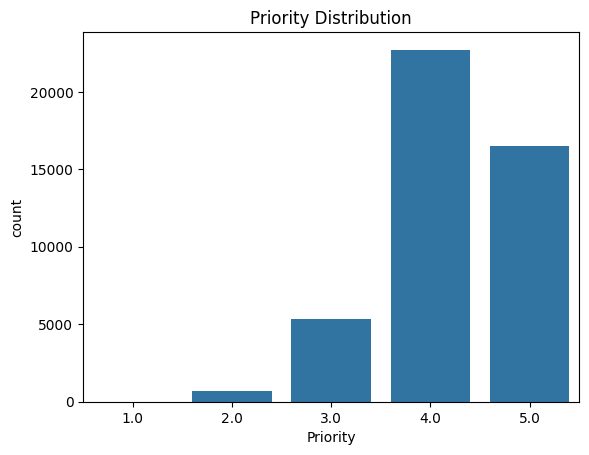

In [50]:
sns.countplot(x='Priority', data=df)

plt.title("Priority Distribution")

plt.show()

## Incident Volume Trend Analysis

Incident trends help identify:
- operational workload growth
- yearly ticket patterns
- forecasting requirements

This analysis supports future incident forecasting models.

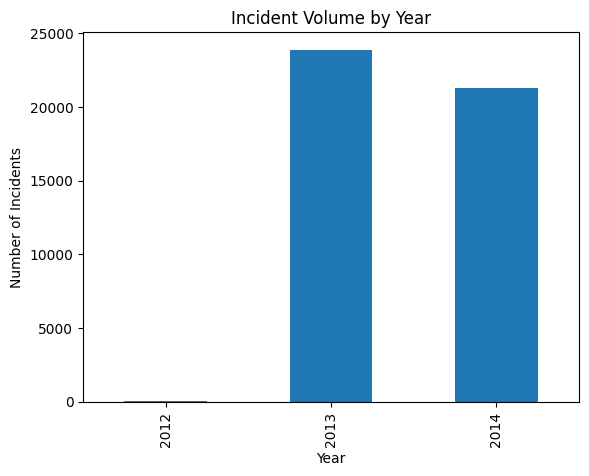

In [51]:
incident_trend = df.groupby('Open_Year').size()

incident_trend.plot(kind='bar')

plt.title("Incident Volume by Year")

plt.xlabel("Year")

plt.ylabel("Number of Incidents")

plt.show()

In [ ]:
## Correlation Analysis

Correlation analysis helps identify relationships between numerical features.

This supports:
- feature selection
- model optimization
- operational insights

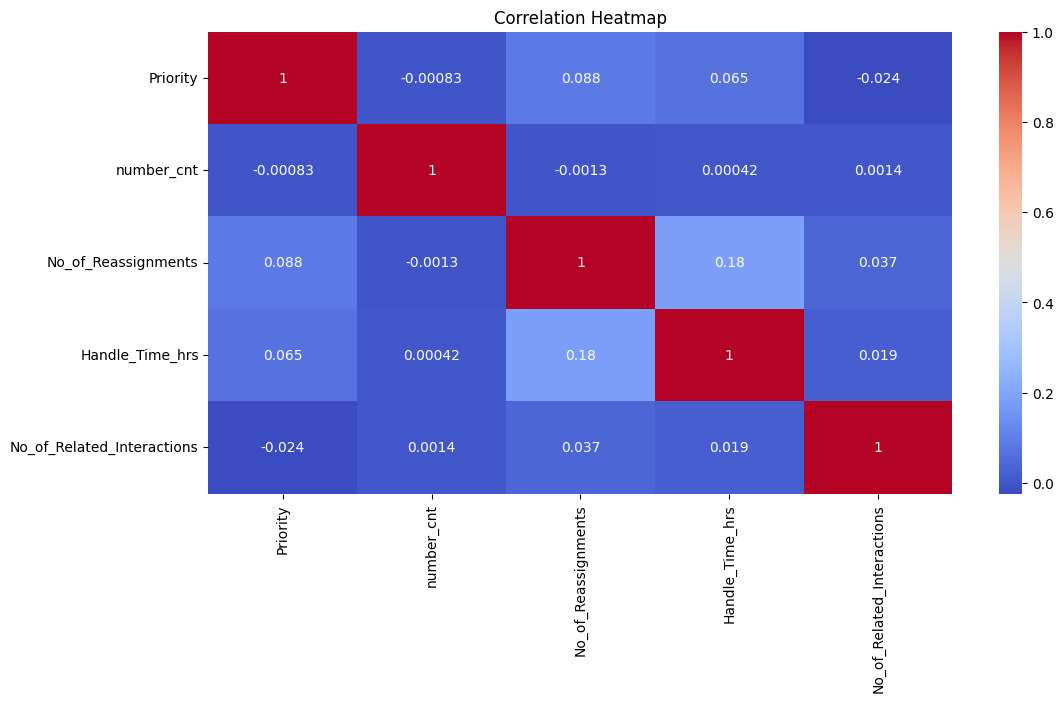

In [52]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
## Final Dataset Validation

Final validation ensures that:
- preprocessing is complete
- missing values are minimized
- dataset is ready for machine learning

In [53]:
df.isnull().sum()

CI_Name                          0
CI_Cat                           0
CI_Subcat                        0
WBS                              0
Incident_ID                      0
Status                           0
Impact                           0
Urgency                          0
Priority                         0
number_cnt                       0
Category                         0
KB_number                        0
Alert_Status                     0
No_of_Reassignments              0
Open_Time                        0
Resolved_Time                 1644
Close_Time                       0
Handle_Time_hrs                  1
Closure_Code                     0
No_of_Related_Interactions       0
Related_Interaction              0
Open_Year                        0
Open_Month                       0
Open_Day                         0
Open_Hour                        0
Open_Weekday                     0
dtype: int64

In [54]:
df.to_csv(
    r"C:\Projects_Dm\ITSM_project\data\processed\itsm_cleaned.csv",
    index=False
)

print("Processed dataset saved successfully")

Processed dataset saved successfully


In [55]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction', 'Open_Year',
       'Open_Month', 'Open_Day', 'Open_Hour', 'Open_Weekday'],
      dtype='str')